# Anomaly Detection
## “How do countries behave over time inside each cluster?”

In [5]:
import matplotlib, importlib.util, os

print("matplotlib file:", matplotlib.__file__)
print("matplotlib version:", getattr(matplotlib, "__version__", None))
print("backends spec:", importlib.util.find_spec("matplotlib.backends"))
print("cwd:", os.getcwd())


matplotlib file: /opt/anaconda3/lib/python3.12/site-packages/matplotlib/__init__.py
matplotlib version: 3.10.7
backends spec: ModuleSpec(name='matplotlib.backends', loader=<_frozen_importlib_external.SourceFileLoader object at 0x1140bb740>, origin='/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends/__init__.py', submodule_search_locations=['/opt/anaconda3/lib/python3.12/site-packages/matplotlib/backends'])
cwd: /Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [6]:
import matplotlib
import matplotlib.backends  # force-attach backends onto matplotlib


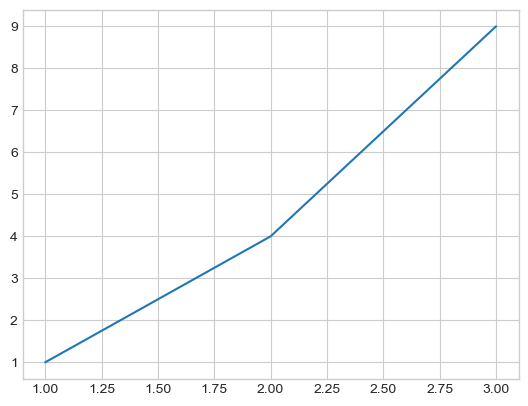

In [7]:
import matplotlib.pyplot as plt
plt.plot([1,2,3],[1,4,9])
plt.show()


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")


In [9]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/anomaly_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


PosixPath('../worldbank_tableau_project/outputs/anomaly_2')

In [10]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [11]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [12]:
pca_df = pd.read_csv('data/Main_Clustering.csv')

In [13]:
pca_df.head()

,country_name,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster,Cluster_Name
0,Algeria,-0.837744,0.597726,-1.528005,-0.095624,-0.702257,-0.137335,0.141079,-0.659615,-0.308707,3,North African Reformers
1,Bahrain,1.900227,0.039329,-0.340081,-0.170821,-0.063872,-0.129657,-0.074608,0.345520,0.495636,1,High-Income Empowerers
2,"Egypt, Arab Rep.",-1.799994,-0.372545,-0.168229,2.279048,-0.561394,1.120786,-0.216897,0.106215,0.285203,2,Fragile States
3,"Iran, Islamic Rep.",-1.443357,-0.298715,0.983355,2.304485,-0.561044,-0.073520,0.075837,-0.660563,0.011879,2,Fragile States
4,Iraq,-2.375472,0.039955,0.165216,-0.658568,1.856444,1.002499,-0.838879,0.447198,-0.060468,2,Fragile States


In [14]:
pca_df.columns

Index(['country_name', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8',
       'PC9', 'Cluster', 'Cluster_Name'],
      dtype='object')

In [15]:
N_PCS = 3
pc_cols = [f"PC{i}" for i in range(1, N_PCS + 1)]


anomaly_df = (
    pca_df[["country_name","Cluster","Cluster_Name"] + pc_cols]
    .set_index("country_name")
    .copy()
)

anomaly_df.head()


,Cluster,Cluster_Name,PC1,PC2,PC3
country_name,,,,,
Algeria,3,North African Reformers,-0.837744,0.597726,-1.528005
Bahrain,1,High-Income Empowerers,1.900227,0.039329,-0.340081
"Egypt, Arab Rep.",2,Fragile States,-1.799994,-0.372545,-0.168229
"Iran, Islamic Rep.",2,Fragile States,-1.443357,-0.298715,0.983355
Iraq,2,Fragile States,-2.375472,0.039955,0.165216


In [16]:
X_anom = anomaly_df[pc_cols].values

iso = IsolationForest(
    n_estimators=200,
    contamination=0.15, 
    random_state=42
)

iso_labels = iso.fit_predict(X_anom) 

iso_raw_scores = iso.decision_function(X_anom) 

anomaly_df["iso_raw_score"] = iso_raw_scores
anomaly_df["iso_anomaly_score"] = -iso_raw_scores # flip: higher = more anomalous
anomaly_df["iso_label"] = np.where(iso_labels == -1, 1, 0)  # 1 = anomaly, 0 = normal

anomaly_df_sorted = anomaly_df.sort_values("iso_anomaly_score", ascending=False)
anomaly_df_sorted.head(15)





,Cluster,Cluster_Name,PC1,PC2,PC3,iso_raw_score,iso_anomaly_score,iso_label
country_name,,,,,,,,
Lebanon,0,Lebanon Outlier,-0.729063,3.136066,2.908014,-0.089973,0.089973,1
West Bank and Gaza,4,Palestine,-0.624159,-3.355717,1.521529,-0.045399,0.045399,1
Morocco,3,North African Reformers,-1.118704,1.106070,-2.427395,-0.015850,0.015850,1
Qatar,1,High-Income Empowerers,3.944395,-0.583992,0.376699,0.012968,-0.012968,0
"Yemen, Rep.",2,Fragile States,-2.902448,-1.372818,-0.466374,0.015127,-0.015127,0
Libya,3,North African Reformers,-0.158361,1.878770,0.239968,0.068374,-0.068374,0
Tunisia,3,North African Reformers,0.200594,0.844160,-1.104354,0.085214,-0.085214,0
Algeria,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0
United Arab Emirates,1,High-Income Empowerers,2.751629,0.145465,-0.283745,0.099882,-0.099882,0


In [17]:
# Save full anomaly table
anomaly_df_sorted.reset_index().to_csv(
    OUTPUT_DIR / "country_anomaly_scores.csv",
    index=False
)


### Global view – Top anomalous countries

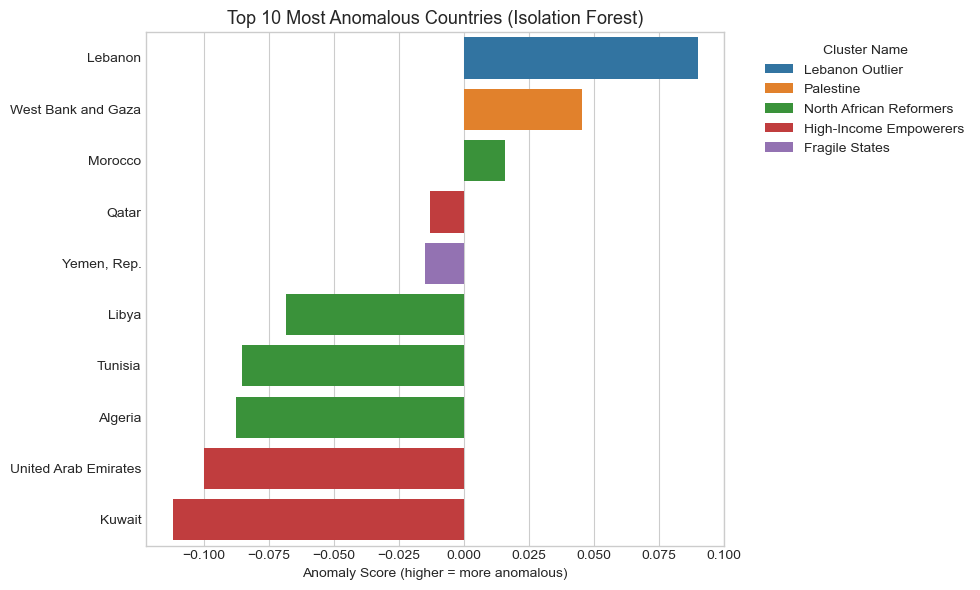

In [18]:
top_n = 10
top_anomalies = (
    anomaly_df_sorted
    .head(top_n)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_anomalies,
    x="iso_anomaly_score",
    y="country_name",
    hue="Cluster_Name",
    dodge=False
)
plt.xlabel("Anomaly Score (higher = more anomalous)")
plt.ylabel("")
plt.title(f"Top {top_n} Most Anomalous Countries (Isolation Forest)", fontsize=13)
plt.legend(title="Cluster Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "iso_top_anomalies_bar.png", dpi=300, bbox_inches="tight")
plt.show()



## PC Contribution — What Drives Each Anomaly?

In [19]:
def get_pc_driver(row):
    pcs = np.array([row["PC1"], row["PC2"], row["PC3"]])
    labels = ["PC1", "PC2", "PC3"]
    return labels[np.argmax(np.abs(pcs))]

# 1. Compute driver
anomaly_df["Anomaly_Driver"] = anomaly_df.apply(get_pc_driver, axis=1)

# 2. Now re-sort AFTER the column exists
anomaly_df_sorted = anomaly_df.sort_values("iso_anomaly_score", ascending=False)

# 3. This will now work
anomaly_df_sorted.head(30)[["iso_anomaly_score", "Anomaly_Driver"]]



,iso_anomaly_score,Anomaly_Driver
country_name,,
Lebanon,0.089973,PC2
West Bank and Gaza,0.045399,PC2
Morocco,0.015850,PC3
Qatar,-0.012968,PC1
"Yemen, Rep.",-0.015127,PC1
Libya,-0.068374,PC2
Tunisia,-0.085214,PC3
Algeria,-0.087545,PC3
United Arab Emirates,-0.099882,PC1


## Anomalies *within* each structural cluster


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_13699/763243678.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


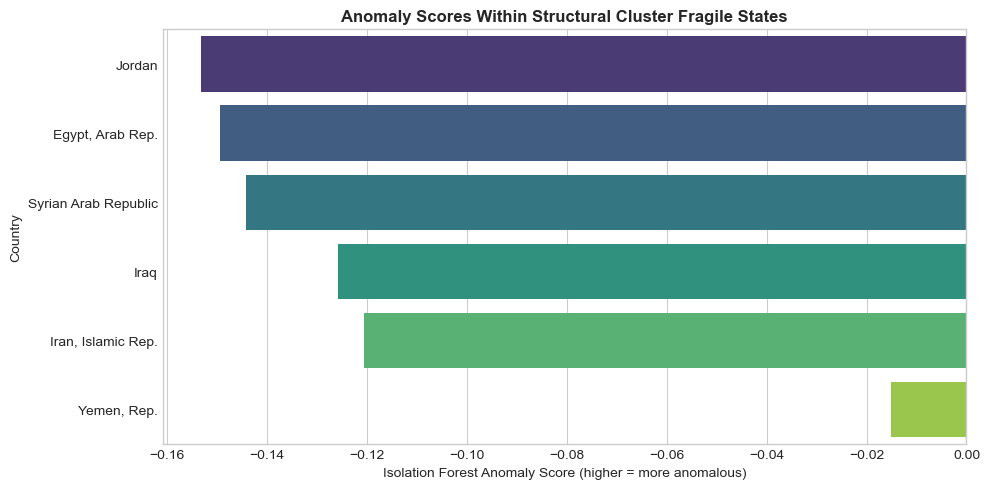

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_13699/763243678.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


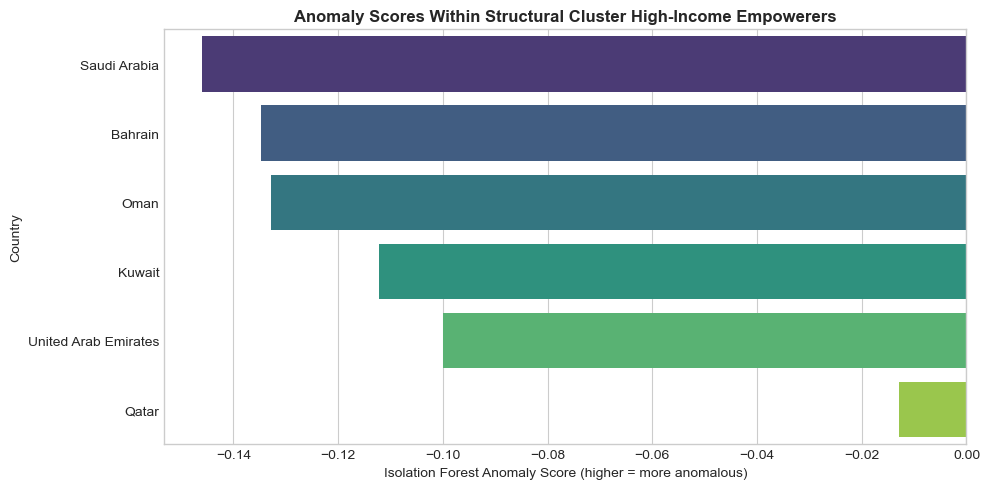

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_13699/763243678.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


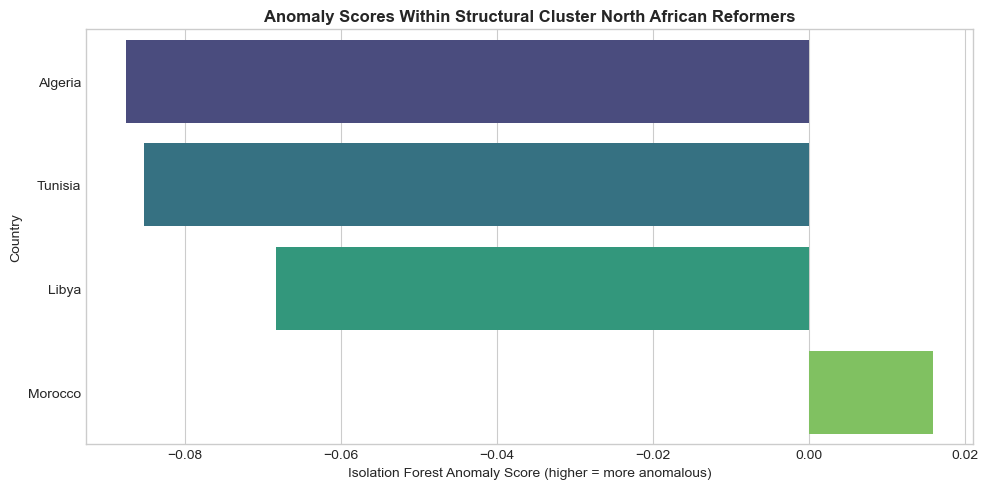

Saved: cluster-level anomaly bar charts.


In [20]:
# ======================================================================
# 5. Visualization 2: Anomalies *within* each structural cluster
# ======================================================================

# Only plot clusters that have at least 2 countries
clusters_to_plot = sorted(
    cname for cname, count in anomaly_df["Cluster_Name"].value_counts().items()
    if count >= 2
)

for cname in clusters_to_plot:
    

    df_cluster = anomaly_df[anomaly_df["Cluster_Name"] == cname].copy()
    df_cluster = df_cluster.sort_values("iso_anomaly_score", ascending=True)
    

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_cluster.reset_index(),
        x="iso_anomaly_score",
        y="country_name",
        palette="viridis"
    )
    plt.title(f"Anomaly Scores Within Structural Cluster {cname}", fontsize=12, fontweight='bold')
    plt.xlabel("Isolation Forest Anomaly Score (higher = more anomalous)")
    plt.ylabel("Country")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"cluster_{cname}_anomaly_bars.png", dpi=300)
    plt.show()

print("Saved: cluster-level anomaly bar charts.")



## PC1 vs PC2

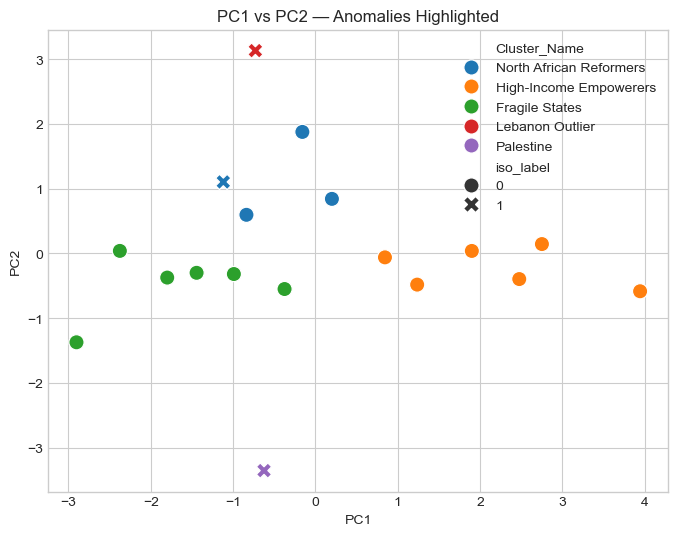

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=anomaly_df,
    x="PC1", y="PC2",
    hue="Cluster_Name",
    style="iso_label",
    palette="tab10",
    s=120
)
plt.title("PC1 vs PC2 — Anomalies Highlighted")
plt.savefig(OUTPUT_DIR / "scatter_PC1_PC2.png", dpi=300)
plt.show()


## PC1 vs anomaly score
####   (Do anomalies sit at extremes or in the middle of the structural gradient?)

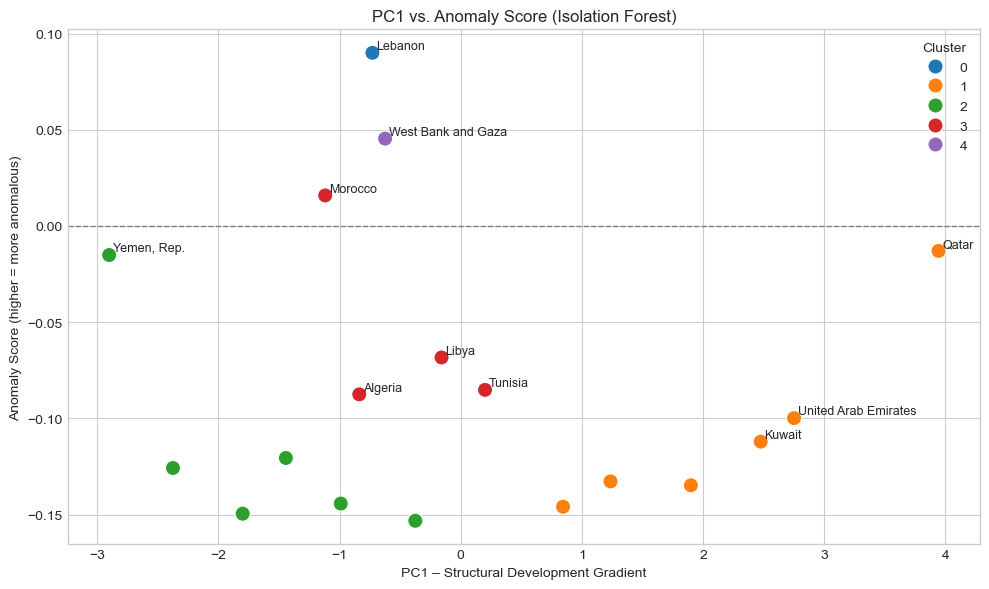

Saved: PC1 vs anomaly scatter plot


In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=anomaly_df,
    x="PC1",
    y="iso_anomaly_score",
    hue="Cluster",
    palette="tab10",
    s=120
)

# Add labels for the most anomalous cases
for _, row in top_anomalies.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["iso_anomaly_score"] + 0.002,
        row["country_name"],
        fontsize=9
    )
    
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("PC1 – Structural Development Gradient")
plt.ylabel("Anomaly Score (higher = more anomalous)")
plt.title("PC1 vs. Anomaly Score (Isolation Forest)")


plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}pc1_vs_anomaly_scatter.png", dpi=300)
plt.show()

print("Saved: PC1 vs anomaly scatter plot")


## Country-level anomaly narrative generator

In [23]:
# ======================================================================
# 8. Country-level anomaly narrative generator
# ======================================================================

def anomaly_narrative(country, df):
    row = df.loc[country]

    cluster = row["Cluster_Name"]
    driver = row["Anomaly_Driver"]
    score = row["iso_anomaly_score"]
    label = "Anomaly" if row["iso_label"] == 1 else "Normal"

    text = f"""
# Anomaly Profile — {country}

**Structural Cluster:** {cluster}  
**Isolation Forest Label:** {label}  
**Anomaly Score:** {score:.4f}  
**Primary Deviation Driver:** {driver}

### Interpretation
{country} diverges from the expected structural behavior of the **{cluster}** cluster.
The strongest deviation occurs along **{driver}**, meaning:

- PC1 → structural / macro-level deviation  
- PC2 → volatility / shock-response deviation  
- PC3 → reform-momentum deviation  

This suggests that the country behaves differently compared to others with similar structural profiles, possibly due to:
- shocks (conflict, crisis, reforms),
- governance instability,
- demographic or economic transformation,
- data inconsistency or rapid shifts.

"""

    return text

# Example
#print(anomaly_narrative("Lebanon", anomaly_df))



In [24]:
for country in anomaly_df.index:
    print(anomaly_narrative(country, anomaly_df))
    print("="*80)  # separator line



# Anomaly Profile — Algeria

**Structural Cluster:** North African Reformers  
**Isolation Forest Label:** Normal  
**Anomaly Score:** -0.0875  
**Primary Deviation Driver:** PC3

### Interpretation
Algeria diverges from the expected structural behavior of the **North African Reformers** cluster.
The strongest deviation occurs along **PC3**, meaning:

- PC1 → structural / macro-level deviation  
- PC2 → volatility / shock-response deviation  
- PC3 → reform-momentum deviation  

This suggests that the country behaves differently compared to others with similar structural profiles, possibly due to:
- shocks (conflict, crisis, reforms),
- governance instability,
- demographic or economic transformation,
- data inconsistency or rapid shifts.



# Anomaly Profile — Bahrain

**Structural Cluster:** High-Income Empowerers  
**Isolation Forest Label:** Normal  
**Anomaly Score:** -0.1348  
**Primary Deviation Driver:** PC1

### Interpretation
Bahrain diverges from the expected structural beh

## Cross Model 

In [25]:
traj_df = pd.read_csv("data/2_df_traj_clusters.csv")
traj_cat_df = (traj_df[["country_name", "traj_cluster", "Cluster_Name"]].drop_duplicates().set_index("country_name"))
traj_cat_df.head()

,traj_cluster,Cluster_Name
country_name,,
Algeria,1,Education-Led Social Improvers
Bahrain,5,Steady Reformers
"Egypt, Arab Rep.",1,Education-Led Social Improvers
"Iran, Islamic Rep.",1,Education-Led Social Improvers
Iraq,1,Education-Led Social Improvers


# ANOMALY FOR CLASSIFICATION

In [27]:
anomaly_df.head()

,Cluster,Cluster_Name,PC1,PC2,PC3,iso_raw_score,iso_anomaly_score,iso_label,Anomaly_Driver
country_name,,,,,,,,,
Algeria,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3
Bahrain,1,High-Income Empowerers,1.900227,0.039329,-0.340081,0.134814,-0.134814,0,PC1
"Egypt, Arab Rep.",2,Fragile States,-1.799994,-0.372545,-0.168229,0.149559,-0.149559,0,PC1
"Iran, Islamic Rep.",2,Fragile States,-1.443357,-0.298715,0.983355,0.120607,-0.120607,0,PC1
Iraq,2,Fragile States,-2.375472,0.039955,0.165216,0.125821,-0.125821,0,PC1


In [28]:
import numpy as np
import pandas as pd

# If anomaly_df already exists in memory, skip reading.
# Otherwise:
# anomaly_df = pd.read_csv("data/anomaly_df.csv")

df = anomaly_df.copy()

# If country_name is the index, bring it back as a column
if df.index.name == "country_name" or "country_name" not in df.columns:
    df = df.reset_index()

df["country_name"] = df["country_name"].astype(str).str.strip()


In [30]:
required = [
    "country_name", "Cluster", "Cluster_Name",
    "iso_label", "iso_anomaly_score", "Anomaly_Driver"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# key sanity checks
if df["country_name"].duplicated().any():
    dupes = df.loc[df["country_name"].duplicated(), "country_name"].tolist()
    raise ValueError(f"Duplicate countries found: {dupes}")

print("Rows:", len(df))
print("iso_label counts:\n", df["iso_label"].value_counts(dropna=False))
print("iso_anomaly_score summary:\n", df["iso_anomaly_score"].describe())


Rows: 18
iso_label counts:
 iso_label
0    15
1     3
Name: count, dtype: int64
iso_anomaly_score summary:
 count    18.000000
mean     -0.079837
std       0.073714
min      -0.153246
25%      -0.134309
50%      -0.105996
75%      -0.028438
max       0.089973
Name: iso_anomaly_score, dtype: float64


In [31]:
df["anomaly_flag"] = df["iso_label"].astype(int)

# intensity: only keep positive signal when flagged, otherwise 0
df["anomaly_intensity"] = np.where(
    df["anomaly_flag"] == 1,
    df["iso_anomaly_score"].astype(float),
    0.0
)


In [33]:
df["anomaly_flag"].value_counts()

anomaly_flag
0    15
1     3
Name: count, dtype: int64

In [34]:
df["anomaly_intensity"].value_counts()

anomaly_intensity
0.000000    15
0.089973     1
0.015850     1
0.045399     1
Name: count, dtype: int64

In [35]:
df.loc[df["anomaly_flag"] == 1, ["country_name", "iso_raw_score", "iso_anomaly_score", "anomaly_intensity", "Anomaly_Driver", "Cluster_Name"]]


,country_name,iso_raw_score,iso_anomaly_score,anomaly_intensity,Anomaly_Driver,Cluster_Name
7,Lebanon,-0.089973,0.089973,0.089973,PC2,Lebanon Outlier
9,Morocco,-0.015850,0.015850,0.015850,PC3,North African Reformers
16,West Bank and Gaza,-0.045399,0.045399,0.045399,PC2,Palestine


In [36]:
df.loc[(df["anomaly_flag"] == 0) & (df["anomaly_intensity"] != 0), ["country_name", "anomaly_flag", "anomaly_intensity"]]


,country_name,anomaly_flag,anomaly_intensity


In [37]:
anomaly_features = df[
    ["country_name", "Cluster", "Cluster_Name",
     "anomaly_flag", "anomaly_intensity", "Anomaly_Driver"]
].copy()

anomaly_features.to_csv("data/anomaly_features.csv", index=False)
anomaly_features.head()


,country_name,Cluster,Cluster_Name,anomaly_flag,anomaly_intensity,Anomaly_Driver
0,Algeria,3,North African Reformers,0,0.0,PC3
1,Bahrain,1,High-Income Empowerers,0,0.0,PC1
2,"Egypt, Arab Rep.",2,Fragile States,0,0.0,PC1
3,"Iran, Islamic Rep.",2,Fragile States,0,0.0,PC1
4,Iraq,2,Fragile States,0,0.0,PC1


### Indicators Imports

In [ ]:
spike_mat = pd.read_csv("traj_indicator_spike_matrix.csv", index_col=0)
outlier_mat = pd.read_csv("traj_indicator_outlier_matrix.csv", index_col=0)
dip_mat = pd.read_csv("traj_indicator_dip_matrix.csv", index_col=0)


In [ ]:
country_spike = traj_cat_df .merge(
    spike_mat,
    left_on="traj_cluster",
    right_index=True,
    how="left"
)

country_dip = traj_cat_df.merge(
    dip_mat,
    left_on="traj_cluster",
    right_index=True,
    how="left"
)

country_outlier = traj_cat_df.merge(
    outlier_mat,
    left_on="traj_cluster",
    right_index=True,
    how="left"
)


In [ ]:
indicator_clusters = spike_mat.columns

combined = traj_cat_df.copy()

for col in indicator_clusters:
    combined[col] = (
        spike_mat[col].reindex(combined["traj_cluster"]).values +
        dip_mat[col].reindex(combined["traj_cluster"]).values +
        outlier_mat[col].reindex(combined["traj_cluster"]).values
    )


In [ ]:
combined[indicator_clusters] = combined[indicator_clusters].apply(pd.to_numeric, errors="coerce")


In [ ]:
combined[indicator_clusters].dtypes


Trajectory_Cluster_Name               float64
Declining Health & Fertility          float64
Fully Stabilized Rights               float64
Gradual Structural Demographic        float64
Growing Participation & Economic      float64
Highly Volatile, Reform-Sensitive     float64
Labor Market Stress & Unemployment    float64
Outlier: Population Dynamics          float64
Stable Legal Rights                   float64
dtype: object

In [ ]:
combined["Primary_Indicator_Behavior"] = combined[indicator_clusters].idxmax(axis=1)


In [ ]:
combined["Primary_Indicator_Behavior"]

country_name
Algeria                      Declining Health & Fertility
Bahrain                               Stable Legal Rights
Egypt, Arab Rep.             Declining Health & Fertility
Iran, Islamic Rep.           Declining Health & Fertility
Iraq                         Declining Health & Fertility
Jordan                  Highly Volatile, Reform-Sensitive
Kuwait                  Highly Volatile, Reform-Sensitive
Lebanon                      Declining Health & Fertility
Libya                        Declining Health & Fertility
Morocco                 Highly Volatile, Reform-Sensitive
Oman                    Highly Volatile, Reform-Sensitive
Qatar                   Highly Volatile, Reform-Sensitive
Saudi Arabia                          Stable Legal Rights
Syrian Arab Republic         Declining Health & Fertility
Tunisia                      Declining Health & Fertility
United Arab Emirates    Highly Volatile, Reform-Sensitive
West Bank and Gaza           Declining Health & Fertility
Y

In [ ]:
c_df = pd.read_csv('data/Main_Clustering.csv')
c_df.head(2)

,country_name,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster,Cluster_Name
0,Algeria,-0.837744,0.597726,-1.528005,-0.095624,-0.702257,-0.137335,0.141079,-0.659615,-0.308707,3,North African Reformers
1,Bahrain,1.900227,0.039329,-0.340081,-0.170821,-0.063872,-0.129657,-0.074608,0.345520,0.495636,1,High-Income Empowerers


In [ ]:
c_df = c_df.set_index("country_name")

In [ ]:
combined.head(2)

,traj_cluster,Cluster_Name,Trajectory_Cluster_Name,Declining Health & Fertility,Fully Stabilized Rights,Gradual Structural Demographic,Growing Participation & Economic,"Highly Volatile, Reform-Sensitive",Labor Market Stress & Unemployment,Outlier: Population Dynamics,Stable Legal Rights,Primary_Indicator_Behavior
country_name,,,,,,,,,,,,
Algeria,1,Education-Led Social Improvers,NaN,0.091049,0.005051,0.051698,0.057870,0.082819,0.037037,0.0,0.020833,Declining Health & Fertility
Bahrain,5,Steady Reformers,NaN,0.083333,0.045455,0.090278,0.119792,0.187500,0.083333,0.0,0.246528,Stable Legal Rights


In [ ]:
indicator_behavior_df = combined[["Primary_Indicator_Behavior"]].copy()
indicator_behavior_df.index.name = "country_name"

indicator_behavior_df.head()

,Primary_Indicator_Behavior
country_name,
Algeria,Declining Health & Fertility
Bahrain,Stable Legal Rights
"Egypt, Arab Rep.",Declining Health & Fertility
"Iran, Islamic Rep.",Declining Health & Fertility
Iraq,Declining Health & Fertility


In [ ]:
print(c_df.index[:5])
print(traj_cat_df.index[:5])
print(indicator_behavior_df.index[:5])
print(anomaly_df.index[:5])


Index(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.', 'Iraq'], dtype='object', name='country_name')
Index(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.', 'Iraq'], dtype='object', name='country_name')
Index(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.', 'Iraq'], dtype='object', name='country_name')
Index(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.', 'Iraq'], dtype='object', name='country_name')


In [ ]:
def build_cross_model_matrix(structural_df, trajectory_df, indicator_df, anomaly_df):
    
    # Rename columns for clarity
    s = structural_df[["Cluster_Name"]].rename(columns={"Cluster_Name": "Structural_Cluster"})
    t = trajectory_df[["Cluster_Name"]].rename(columns={"Cluster_Name": "Trajectory_Cluster"})
    i = indicator_df[["Primary_Indicator_Behavior"]].rename(columns={"Primary_Indicator_Behavior": "Indicator_Cluster"})
    a = anomaly_df[["iso_anomaly_score"]].rename(columns={"iso_anomaly_score": "Anomaly_Score"})

    # Merge all on country index
    merged = (
        s.join(t, how="inner")
         .join(i, how="inner")
         .join(a, how="inner")
    )

    return merged


In [ ]:
def interpret_country(row):
    s = row["Structural_Cluster"]
    t = row["Trajectory_Cluster"]
    i = row["Indicator_Cluster"]
    a = row["Anomaly_Score"]

    # Simple anomaly thresholding
    if a > 0.03:
        anomaly_text = "High anomaly density — likely due to crisis, instability, or rapid structural change."
    elif a > 0.00:
        anomaly_text = "Moderate anomaly density — partial disruptions or unusual indicator combinations."
    else:
        anomaly_text = "Low anomaly density — stable, predictable structural-trajectory alignment."

    return (
        f"{t} trajectory emerging from {s} structural base, "
        f"driven mainly by {i} indicators. {anomaly_text}"
    )


In [ ]:
cross_matrix = build_cross_model_matrix(c_df,
                                        traj_cat_df,
                                        indicator_behavior_df,
                                        anomaly_df)


cross_matrix["Interpretation"] = cross_matrix.apply(interpret_country, axis=1)

cross_matrix.head(10)


,Structural_Cluster,Trajectory_Cluster,Indicator_Cluster,Anomaly_Score,Interpretation
country_name,,,,,
Algeria,North African Reformers,Education-Led Social Improvers,Declining Health & Fertility,-0.087545,Education-Led Social Improvers trajectory emer...
Bahrain,High-Income Empowerers,Steady Reformers,Stable Legal Rights,-0.134814,Steady Reformers trajectory emerging from High...
"Egypt, Arab Rep.",Fragile States,Education-Led Social Improvers,Declining Health & Fertility,-0.149559,Education-Led Social Improvers trajectory emer...
"Iran, Islamic Rep.",Fragile States,Education-Led Social Improvers,Declining Health & Fertility,-0.120607,Education-Led Social Improvers trajectory emer...
Iraq,Fragile States,Education-Led Social Improvers,Declining Health & Fertility,-0.125821,Education-Led Social Improvers trajectory emer...
Jordan,Fragile States,Steady Moderate Improvers,"Highly Volatile, Reform-Sensitive",-0.153246,Steady Moderate Improvers trajectory emerging ...
Kuwait,High-Income Empowerers,Steady Moderate Improvers,"Highly Volatile, Reform-Sensitive",-0.112110,Steady Moderate Improvers trajectory emerging ...
Lebanon,Lebanon Outlier,Education-Led Social Improvers,Declining Health & Fertility,0.089973,Education-Led Social Improvers trajectory emer...
Libya,North African Reformers,Education-Led Social Improvers,Declining Health & Fertility,-0.068374,Education-Led Social Improvers trajectory emer...


In [ ]:
def generate_country_narrative(row):

    country = row.name
    structural = row["Structural_Cluster"]
    trajectory = row["Trajectory_Cluster"]
    indicator = row["Indicator_Cluster"]
    anomaly = row["Anomaly_Score"]
    interpretation = row["Interpretation"]

    narrative = f"""
# {country}: Integrated Model Profile

**Structural Cluster:** {structural}  
**Trajectory Cluster:** {trajectory}  
**Primary Indicator Behavior:** {indicator}  
**Anomaly Score:** {anomaly:.4f}

### Interpretation
{interpretation}
"""

    return narrative




In [ ]:
all_narratives = {}

for country, row in cross_matrix.iterrows():
    all_narratives[country] = generate_country_narrative(row)

# Preview samples
list(all_narratives.items())[:2]




[('Algeria',
  '\n# Algeria: Integrated Model Profile\n\n**Structural Cluster:** North African Reformers  \n**Trajectory Cluster:** Education-Led Social Improvers  \n**Primary Indicator Behavior:** Declining Health & Fertility  \n**Anomaly Score:** -0.0875\n\n### Interpretation\nEducation-Led Social Improvers trajectory emerging from North African Reformers structural base, driven mainly by Declining Health & Fertility indicators. Low anomaly density — stable, predictable structural-trajectory alignment.\n'),
 ('Bahrain',
  '\n# Bahrain: Integrated Model Profile\n\n**Structural Cluster:** High-Income Empowerers  \n**Trajectory Cluster:** Steady Reformers  \n**Primary Indicator Behavior:** Stable Legal Rights  \n**Anomaly Score:** -0.1348\n\n### Interpretation\nSteady Reformers trajectory emerging from High-Income Empowerers structural base, driven mainly by Stable Legal Rights indicators. Low anomaly density — stable, predictable structural-trajectory alignment.\n')]

In [ ]:
import os

#output_dir = "country_reports"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for country, narrative in all_narratives.items():
    filename = f"{OUTPUT_DIR}/{country.replace(',', '').replace(' ', '_')}.md"
    with open(filename, "w") as f:
        f.write(f"# {country} — Cross-Model Report\n\n")
        f.write(narrative)

print("Markdown reports saved.")


Markdown reports saved.


In [ ]:
cross_matrix.to_csv(f"{OUTPUT_DIR}/cross_model_master.csv")


In [ ]:
cross_matrix.to_parquet(f"{OUTPUT_DIR}/cross_model_master.parquet")


In [ ]:
import os

folder = "/Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/anomaly_2/country_narratives"
all_docs = []

for file in sorted(os.listdir(folder)):
    if file.endswith(".md"):
        with open(os.path.join(folder, file), "r") as f:
            all_docs.append(f.read())

full_report = "\n\n---\n\n".join(all_docs)

with open(f"{OUTPUT_DIR}country_narratives_full.md", "w") as f:
    f.write(full_report)


In [ ]:
anomaly_df.head()

,Cluster,Cluster_Name,PC1,PC2,PC3,iso_raw_score,iso_anomaly_score,iso_label,Anomaly_Driver
country_name,,,,,,,,,
Algeria,3,North African Reformers,-0.837744,0.597726,-1.528005,0.087545,-0.087545,0,PC3
Bahrain,1,High-Income Empowerers,1.900227,0.039329,-0.340081,0.134814,-0.134814,0,PC1
"Egypt, Arab Rep.",2,Fragile States,-1.799994,-0.372545,-0.168229,0.149559,-0.149559,0,PC1
"Iran, Islamic Rep.",2,Fragile States,-1.443357,-0.298715,0.983355,0.120607,-0.120607,0,PC1
Iraq,2,Fragile States,-2.375472,0.039955,0.165216,0.125821,-0.125821,0,PC1


Error in callback <function _enable_matplotlib_integration.<locals>.configure_once at 0x1685cc860> (for post_run_cell), with arguments args (<ExecutionResult object at 16a706d80, execution_count=15 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 16a707110, raw_cell="anomaly_df.head()" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks/Anomaly.ipynb#Y100sZmlsZQ%3D%3D> result=                    Cluster             Cluster_Name       PC1       PC2  \
country_name                                                               
Algeria                   3  North African Reformers -0.837744  0.597726   
Bahrain                   1   High-Income Empowerers  1.900227  0.039329   
Egypt, Arab Rep.          2           Fragile States -1.799994 -0.372545   
Iran, Islamic Rep.        2           Fragile States -1.443357 -0.298715   
Iraq                      2           Fragile St

AttributeError: module 'matplotlib' has no attribute 'backends'

In [ ]:
anomaly_df.to_csv("data/anomaly_df.csv")